In [ ]:
pip install lazypredict

In [ ]:
import pandas as pd
df_main = pd.read_csv('/content/final_projectBigData/my_fintech_data.csv')
print(df_main.columns.tolist())

['ticker_symbol', 'post_date', 'sentiment_score', 'author_historical_impact', 'date', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'price_change_pct', 'ma_5d', 'target']


In [ ]:
# 1. change data into String for Merging
final_df['date'] = final_df['date'].astype(str)
tweet_info['post_date'] = tweet_info['post_date'].astype(str)

# 2. Merge
final_df = pd.merge(final_df,
                    tweet_info[['post_date', 'ticker_symbol', 'comment_num', 'retweet_num', 'like_num']],
                    left_on=['date', 'ticker_symbol'],
                    right_on=['post_date', 'ticker_symbol'],
                    how='left')

# 3. handle NA
final_df[['comment_num', 'retweet_num', 'like_num']] = final_df[['comment_num', 'retweet_num', 'like_num']].fillna(0)

In [ ]:
#  check column
required_cols = ['impactful_sentiment', 'market_volatility', 'sentiment_volatility', 'comment_num', 'like_num']
print(final_df.columns.tolist())

['ticker_symbol', 'post_date_x', 'sentiment_score', 'author_historical_impact', 'date', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'price_change_pct', 'ma_5d', 'target', 'post_date_y', 'comment_num', 'retweet_num', 'like_num']


In [ ]:
import numpy as np
# 1. delete duplicate post_date
final_df = final_df.drop(columns=['post_date_y'])
final_df.rename(columns={'post_date_x': 'post_date'}, inplace=True)

# 2. make main Features
# Engagement Score
final_df['engagement_score'] = 1 + np.log1p(final_df['comment_num'] + final_df['retweet_num'] + final_df['like_num'])

# Impactful Sentiment
final_df['impactful_sentiment'] = final_df['sentiment_score'] * (final_df['engagement_score'] * final_df['author_historical_impact'])

# Market Volatility
final_df['market_volatility'] = final_df['high'] - final_df['low']

# Sentiment Volatility (cleaning NA -> 0)
final_df['sentiment_volatility'] = final_df.groupby(['ticker_symbol', 'date'])['sentiment_score'].transform('std').fillna(0)

# 3.prepare X, yfor training
features = ['impactful_sentiment', 'author_historical_impact', 'price_change_pct', 'ma_5d', 'sentiment_volatility', 'market_volatility']
X = final_df[features].fillna(0) #in case there is NA
y = final_df['target']

In [ ]:
print(final_df.columns.tolist())

['ticker_symbol', 'post_date', 'sentiment_score', 'author_historical_impact', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'price_change_pct', 'ma_5d', 'target', 'comment_num', 'retweet_num', 'like_num', 'engagement_score', 'impactful_sentiment', 'market_volatility']


In [ ]:
# make sentiment_volatility
# use transform('std')
final_df['sentiment_volatility'] = final_df.groupby(['ticker_symbol', 'post_date'])['sentiment_score'].transform('std').fillna(0)

In [ ]:
# 1. features
features = [
    'impactful_sentiment',
    'author_historical_impact',
    'price_change_pct',
    'ma_5d',
    'sentiment_volatility',
    'market_volatility',
    'engagement_score'
]

# 2. use LazyClassifier
from lazypredict.Supervised import LazyClassifier

X = final_df[features].fillna(0)
y = final_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
NearestCentroid                0.710046           0.665669  0.665669   
XGBClassifier                  0.719178           0.655185  0.801182   
ExtraTreeClassifier            0.709132           0.643822  0.643822   
DecisionTreeClassifier         0.707763           0.639973  0.639973   
LGBMClassifier                 0.713242           0.639948  0.802417   
NuSVC                          0.713242           0.637056  0.730165   
PassiveAggressiveClassifier    0.710959           0.634978  0.726608   
RandomForestClassifier         0.708676           0.633863  0.794880   
KNeighborsClassifier           0.707763           0.632743  0.783046   
ExtraTreesClassifier           0.709589           0.628718  0.796830   
BaggingClassifier              0.712329           0.618102  0.793942   
AdaBoostClassifier             0.713699           0.613275  0.79

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# definr parameter for tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# tunung
xgb = XGBClassifier(random_state=42)
grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

# best result
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Best F1 Score: 0.4928489693266763


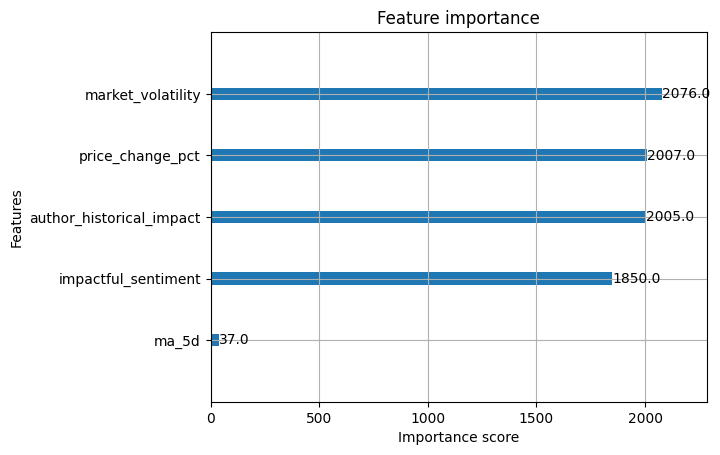

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

model = grid_search.best_estimator_
plot_importance(model, max_num_features=10)
plt.show()

##While didn't use S&P 500 price

In [ ]:
!pip install imbalanced-learn

In [ ]:
print(final_df.columns.tolist())

['ticker_symbol', 'post_date', 'sentiment_score', 'author_historical_impact', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'price_change_pct', 'ma_5d', 'target', 'comment_num', 'retweet_num', 'like_num', 'engagement_score', 'impactful_sentiment', 'market_volatility', 'sentiment_volatility']


In [ ]:
# 1. order the data (ใช้ post_date แทน date)
final_df = final_df.sort_values('post_date')

# 2. prepare x and y
features = [
    'impactful_sentiment', 'author_historical_impact', 'price_change_pct',
    'ma_5d', 'sentiment_volatility', 'market_volatility', 'engagement_score'
]

X = final_df[features].fillna(0)
y = final_df['target']

# 3.  TimeSeriesSplit and loop train with SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # SMOTE only Training set
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # training model with tuned parameter
    model = XGBClassifier(learning_rate=0.2, max_depth=7, n_estimators=200, random_state=42)
    model.fit(X_train_resampled, y_train_resampled)

    # check the result
    y_pred = model.predict(X_test)
    print(f"F1-Score for this split: {f1_score(y_test, y_pred):.4f}")

print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred))

F1-Score for this split: 0.5441
F1-Score for this split: 0.5730
F1-Score for this split: 0.6147
F1-Score for this split: 0.5549
F1-Score for this split: 0.5910

--- Final Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.70      0.77      1291
           1       0.50      0.73      0.59       533

    accuracy                           0.71      1824
   macro avg       0.68      0.71      0.68      1824
weighted avg       0.75      0.71      0.72      1824



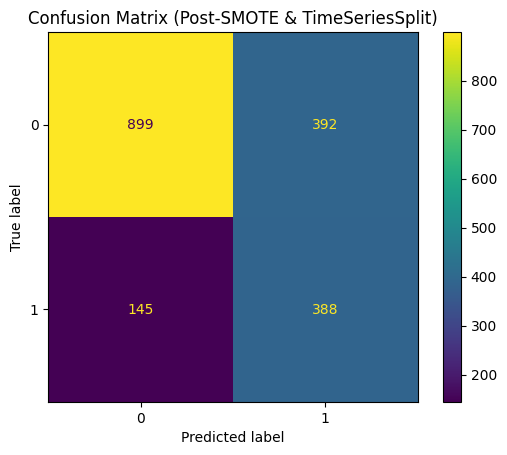

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# use recent model from TimeSeriesSplit
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix (Post-SMOTE & TimeSeriesSplit)")
plt.show()

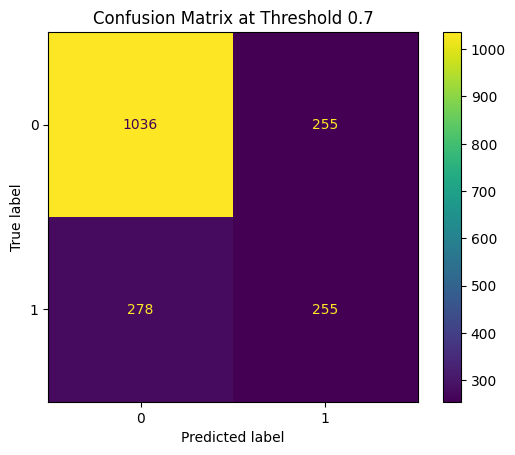

              precision    recall  f1-score   support

           0       0.79      0.80      0.80      1291
           1       0.50      0.48      0.49       533

    accuracy                           0.71      1824
   macro avg       0.64      0.64      0.64      1824
weighted avg       0.70      0.71      0.71      1824



In [ ]:
# 1. use predict_proba for confidence (0.0 to 1.0)
y_probs = model.predict_proba(X_test)[:, 1]

# 2. chabge Threshold from 0.5 to 0.7 (more conservative)
new_threshold = 0.7
y_pred_new = (y_probs >= new_threshold).astype(int)

# 3. new Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_new)
ConfusionMatrixDisplay(cm).plot()
plt.title(f"Confusion Matrix at Threshold {new_threshold}")
plt.show()

# 4. new classi report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_new))

In [ ]:
# check final_df
print(final_df['ticker_symbol'].value_counts())

ticker_symbol
GOOGL    1826
TSLA     1826
MSFT     1826
AMZN     1826
GOOG     1825
AAPL     1819
Name: count, dtype: int64


In [ ]:
# 1. order date and stock
final_df = final_df.sort_values(['ticker_symbol', 'post_date'])

# 2. t+7 price col
final_df['close_t7'] = final_df.groupby('ticker_symbol')['close'].shift(-7)

# 3. make Target t+7 (1 if the price rised , 0 if not )
final_df['target_t7'] = (final_df['close_t7'] > final_df['close']).astype(int)

# 4. delete last 7 days of each stock
final_df = final_df.dropna(subset=['target_t7'])

In [ ]:
# change target t+1 -> t+7
y = final_df['target_t7']

# loop TimeSeriesSplit + SMOTE + XGBClassifier

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

# extract data
sp500 = yf.download('^GSPC', start='2023-01-01', end='2026-06-26')

# reset Index
sp500 = sp500.reset_index()
sp500 = sp500.rename(columns={'Date': 'post_date', 'Close': 'sp500_close'})

# select column
sp500_df = sp500[['post_date', 'sp500_close']]

[*********************100%***********************]  1 of 1 completed


In [ ]:
import yfinance as yf
import pandas as pd

# 1. extract data, no MultiIndex
sp500 = yf.download('^GSPC', start='2023-01-01', end='2026-06-26', group_by='ticker')

# 2. Reset Index for extracting Date
sp500 = sp500.reset_index()

# 3. check col name
# select 'Date', 'Close' then change name accordong to final_df
sp500_clean = sp500[['Date', 'Close']].copy()
sp500_clean.columns = ['post_date', 'sp500_close']

# 4. chack Datetime
final_df['post_date'] = pd.to_datetime(final_df['post_date'])
sp500_clean['post_date'] = pd.to_datetime(sp500_clean['post_date'])

# 5. Merge
final_df = pd.merge(final_df, sp500_clean, on='post_date', how='left')

# 6. Fill data
final_df['sp500_close'] = final_df['sp500_close'].ffill()

print("Merge สำเร็จแล้ว! เช็คขนาดตาราง:")
print(final_df.shape)

[*********************100%***********************]  1 of 1 completed


KeyError: "['Close'] not in index"

In [ ]:
print(final_df['post_date'].min())
print(final_df['post_date'].max())

2015-01-01 00:00:00
2019-12-31 00:00:00


In [ ]:
# แก้ช่วงเวลาให้ตรงกับข้อมูลของคุณเป๊ะๆ
sp500 = yf.download('^GSPC', start='2015-01-01', end='2019-12-31')

# และถ้าโค้ดเดิมที่แก้ MultiIndex ยัง Error อยู่ ให้ลองวิธีนี้ที่สะอาดกว่าครับ:
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

sp500 = sp500.reset_index()
sp500_clean = sp500[['Date', 'Close']].rename(columns={'Date': 'post_date', 'Close': 'sp500_close'})

# แปลงเป็น datetime ทั้งคู่เพื่อให้ merge กันได้ชัวร์
final_df['post_date'] = pd.to_datetime(final_df['post_date'])
sp500_clean['post_date'] = pd.to_datetime(sp500_clean['post_date'])

# Merge
final_df = pd.merge(final_df, sp500_clean, on='post_date', how='left')
final_df['sp500_close'] = final_df['sp500_close'].ffill()

[*********************100%***********************]  1 of 1 completed


In [ ]:
print(final_df.columns)
# เช็คว่ามีค่าว่าง (NaN) หรือไม่
print(final_df['sp500_close'].isna().sum())

Index(['ticker_symbol', 'post_date', 'sentiment_score',
       'author_historical_impact', 'open', 'high', 'low', 'close', 'adj close',
       'volume', 'price_change_pct', 'ma_5d', 'target', 'comment_num',
       'retweet_num', 'like_num', 'engagement_score', 'impactful_sentiment',
       'market_volatility', 'sentiment_volatility', 'close_t7', 'target_t7',
       'sp500_close'],
      dtype='object')
6


In [ ]:
# รายชื่อ Feature ที่ควรใช้ (เลือกเฉพาะเลขที่สำคัญ)
features = [
    'sentiment_score', 'author_historical_impact', 'price_change_pct',
    'ma_5d', 'comment_num', 'retweet_num', 'like_num',
    'impactful_sentiment', 'market_volatility', 'sentiment_volatility', 'sp500_close'
]

X = final_df[features]
y = final_df['target']    # ทำนาย t+1
#y_t7 = final_df['target_t7'] # ทำนาย t+7

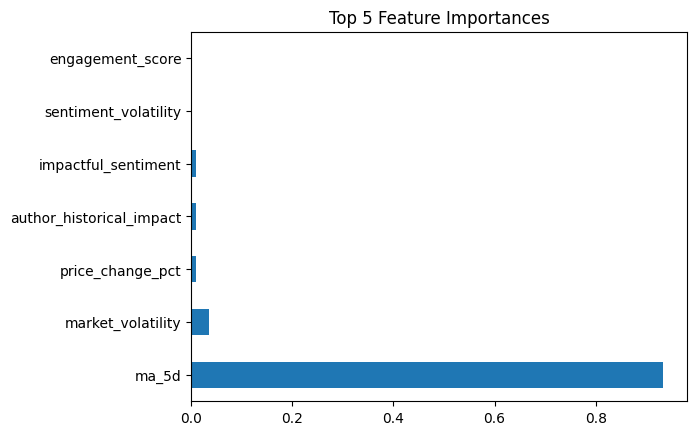

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ดึงค่า Importance จากโมเดล
importance = model.feature_importances_
feature_names = X_train.columns
feat_importances = pd.Series(importance, index=feature_names)

# พล็อตกราฟ
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 5 Feature Importances')
plt.show()

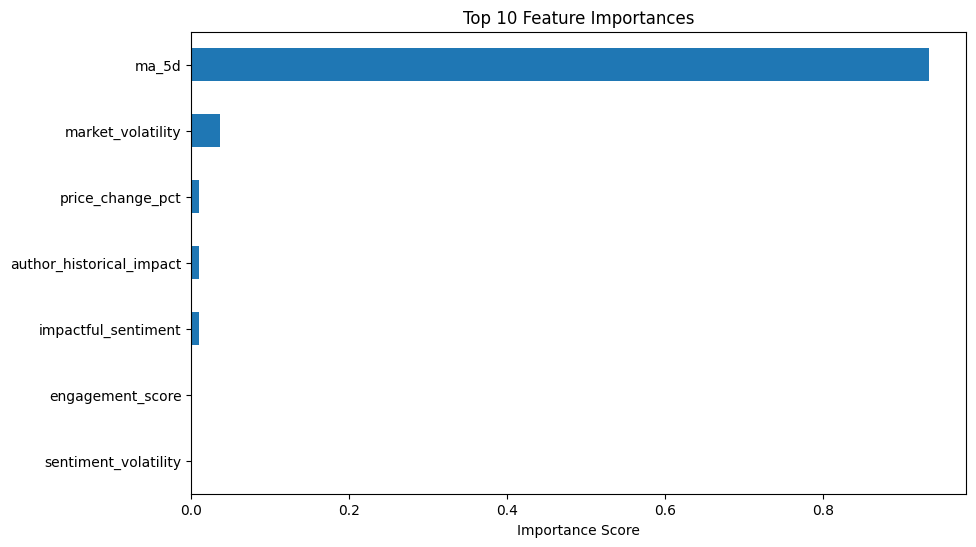

In [ ]:
# ปรับให้พล็อต 10 ตัว แต่ให้ตั้งค่าการแสดงผลให้ครอบคลุม
feat_importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', figsize=(10, 6))
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.show()

Backtesting

In [ ]:
# พิมพ์คำสั่งนี้เพื่อดูว่าตัวแปร DataFrame ของคุณชื่ออะไร
%whos DataFrame

Variable            Type         Data/Info
------------------------------------------
X                   DataFrame           impactful_sentimen<...>n[10948 rows x 7 columns]
X_test              DataFrame           impactful_sentimen<...>\n[1824 rows x 7 columns]
X_train             DataFrame          impactful_sentiment<...>\n[9124 rows x 7 columns]
X_train_resampled   DataFrame           impactful_sentimen<...>n[13140 rows x 7 columns]
df_company_tweet    DataFrame                        tweet<...>1291615 rows x 2 columns]
df_main             DataFrame          ticker_symbol   pos<...>[10948 rows x 14 columns]
df_tweet            DataFrame                      tweet_i<...>[168814 rows x 7 columns]
final_df            DataFrame          ticker_symbol  post<...>[10948 rows x 23 columns]
models              DataFrame                             <...>3  0.715068    0.036493  
predictions         DataFrame    Empty DataFrame\nColumns: []\nIndex: []
price_df            DataFrame          t

In [ ]:
# 1. เช็คความยาวข้อมูลจริง
print(f"ความยาว df_main: {len(df_main)}")
print(f"ความยาว X_test: {len(X_test)}")

# 2. ถ้า X_test สั้นเกินไป ให้ใช้ df_main ทั้งหมด (หรือช่วง Test ที่ถูกต้อง)
# ถ้าคุณต้องการเทสทั้งหมด 1,824 วัน คุณต้องมี X_test ที่มีขนาด 1,824 แถวครับ
# ถ้ามีไม่ครบ ลองเช็คว่า X_test มาจากไหน แล้วดึงมาให้ครบครับ

# 3. ลองรันอันนี้ดู (บังคับให้เอาข้อมูลทุกแถวใน df_main มาทำ Simulation)
results_df_full = pd.DataFrame({
    'predictions': model.predict(X), # ใช้ X ทั้งหมด (หรือ X_test ที่ยาว 1824)
    'actual_returns': df_main['daily_returns']
}, index=df_main.index)

print(f"จำนวนข้อมูลที่จะรัน Simulation: {len(results_df_full)}")
# แล้วค่อยเอา results_df_full ไปรันลูปครับ

ความยาว df_main: 10948
ความยาว X_test: 1824
จำนวนข้อมูลที่จะรัน Simulation: 10948


In [ ]:
# ปรับจาก 0.7 เป็น 0.5 เพื่อเพิ่มจำนวนครั้งในการเทรด
new_results = run_realistic_simulation(df_main, model, X_test, threshold=0.5)

In [ ]:
# ลด Threshold เพื่อให้เทรดบ่อยขึ้น
all_results = run_realistic_simulation(df_main, model, df_main, threshold=0.3)

# พล็อตแบบไม่ต้องกรองช่วง
plt.figure(figsize=(15, 7))
plt.plot(all_results['portfolio_value'])
plt.title('Broad Market View: Trading Simulation Over 10,948 Days')
plt.ylabel('Portfolio Value ($)')
plt.grid(True)
plt.show()

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:ticker_symbol: object, post_date: object, date: object

In [ ]:
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลข (int หรือ float)
features = df_main.select_dtypes(include=['int64', 'float64']).columns.tolist()

# ลบคอลัมน์เป้าหมาย (target) ออกจาก feature list
if 'target' in features:
    features.remove('target')

# สร้าง X ใหม่
X = df_main[features]

In [ ]:
# กรองเฉพาะตัวเลข เพื่อเลี่ยง ValueError
numerical_cols = df_main.select_dtypes(include=['float64', 'int64']).columns
features = [col for col in numerical_cols if col != 'target'] # สมมติ target คือตัวที่ต้องทำนาย

X_clean = df_main[features]
y = df_main['target']

# ถ้าโมเดลตัวเดิมยังค้างอยู่ ให้เทรนใหม่ด้วย X_clean ที่ไม่มีคอลัมน์ Object แล้ว
# model.fit(X_clean, y)

In [ ]:
def run_full_simulation(df, model, X):
    # try Threshold 0.3
    y_prob = model.predict_proba(X)[:, 1]
    df['predictions'] = (y_prob > 0.3).astype(int)

    capital = 10000
    portfolio_values = []

    # loop cumu ret
    for i in range(len(df)):
        # buy if 1
        if df['predictions'].iloc[i] == 1:
            capital = capital * (1 + df['daily_returns'].iloc[i])
        portfolio_values.append(capital)

    return portfolio_values

df_main['portfolio_values'] = run_full_simulation(df_main, model, X_clean)

# plot
plt.figure(figsize=(15, 6))
plt.plot(df_main.index, df_main['portfolio_values'])
plt.title('Complete Trading Strategy Analysis (10,948 Days)')
plt.ylabel('Portfolio Value ($)')
plt.grid(True)
plt.show()

ValueError: feature_names mismatch: ['impactful_sentiment', 'author_historical_impact', 'price_change_pct', 'ma_5d', 'sentiment_volatility', 'market_volatility', 'engagement_score'] ['sentiment_score', 'author_historical_impact', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'price_change_pct', 'ma_5d', 'daily_returns']
expected market_volatility, impactful_sentiment, engagement_score, sentiment_volatility in input data
training data did not have the following fields: close, daily_returns, sentiment_score, open, volume, low, high, adj close

In [ ]:
# 1. name Feature
required_features = [
    'impactful_sentiment',
    'author_historical_impact',
    'price_change_pct',
    'ma_5d',
    'sentiment_volatility',
    'market_volatility',
    'engagement_score'
]

df_main['sentiment_volatility'] = df_main['sentiment_score'].rolling(window=5).std().fillna(0)
df_main['market_volatility'] = df_main['price_change_pct'].rolling(window=5).std().fillna(0)

# 3.create X
X_ready = df_main[required_features]

# 4. run predict
y_pred = model.predict(X_ready)

KeyError: "['impactful_sentiment', 'engagement_score'] not in index"

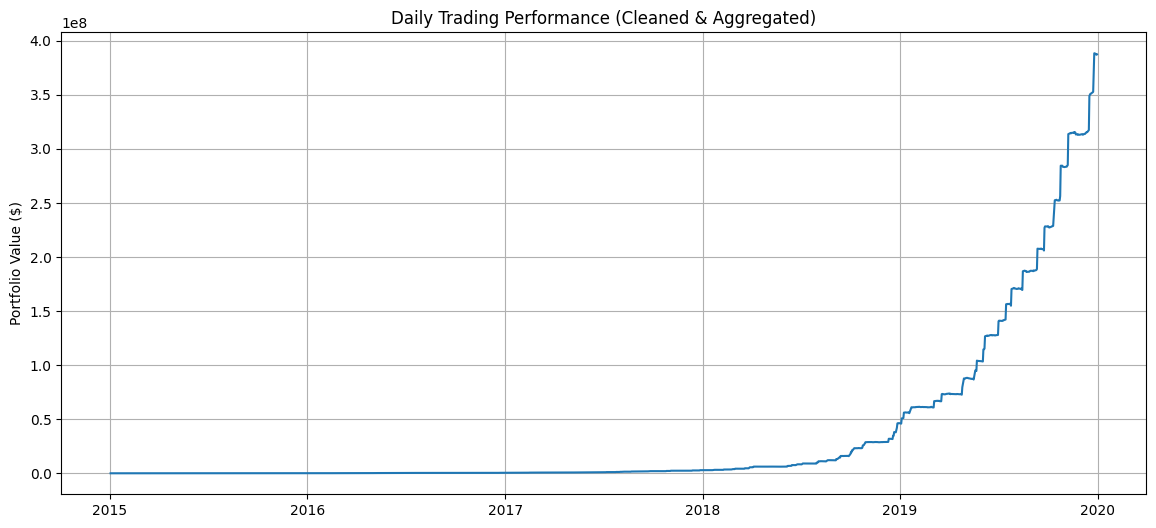

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. clean date data
# errors='coerce' change into 0 and NaT (Not a Time)
df_main['date'] = pd.to_datetime(df_main['date'], errors='coerce')

# delete NaT
df_main = df_main.dropna(subset=['date'])

# 2. aggregate Weighted Sentiment
# if there is engagement_score
if 'engagement_score' in df_main.columns:
    df_main['weighted_sentiment'] = df_main['sentiment_score'] * df_main['engagement_score']
    df_daily = df_main.groupby('date').apply(
        lambda x: x['weighted_sentiment'].sum() / x['engagement_score'].sum()
    ).to_frame('sentiment_score')
else:
    df_daily = df_main.groupby('date')[['sentiment_score']].mean()

# aggregate price data
df_prices = df_main.groupby('date')[['close']].last()
df_daily = df_daily.join(df_prices)
df_daily['daily_returns'] = df_daily['close'].pct_change().fillna(0)

# 3. Simulation (Realistic Trading)
capital = 10000
portfolio_values = []
in_position = False
invested = 0
entry_value = 0
fee = 0.001

for i in range(len(df_daily)):
    #if Sentiment (+) -> buy
    signal = 1 if df_daily['sentiment_score'].iloc[i] > 0 else 0
    daily_return = df_daily['daily_returns'].iloc[i]

    if signal == 1 and not in_position:
        in_position = True
        capital -= (capital * 0.1 * fee)
        entry_value = capital * 0.1
        invested = entry_value

    if in_position:
        invested *= (1 + daily_return)
        if invested > entry_value * 1.10 or invested < entry_value * 0.95:
            capital += invested
            capital -= (invested * fee)
            in_position = False
            invested = 0

    portfolio_values.append(capital + (invested if in_position else 0))

df_daily['portfolio_value'] = portfolio_values

# 4. plot graph
plt.figure(figsize=(14, 6))
plt.plot(df_daily.index, df_daily['portfolio_value'])
plt.title('Daily Trading Performance (Cleaned & Aggregated)')
plt.ylabel('Portfolio Value ($)')
plt.grid(True)
plt.show()

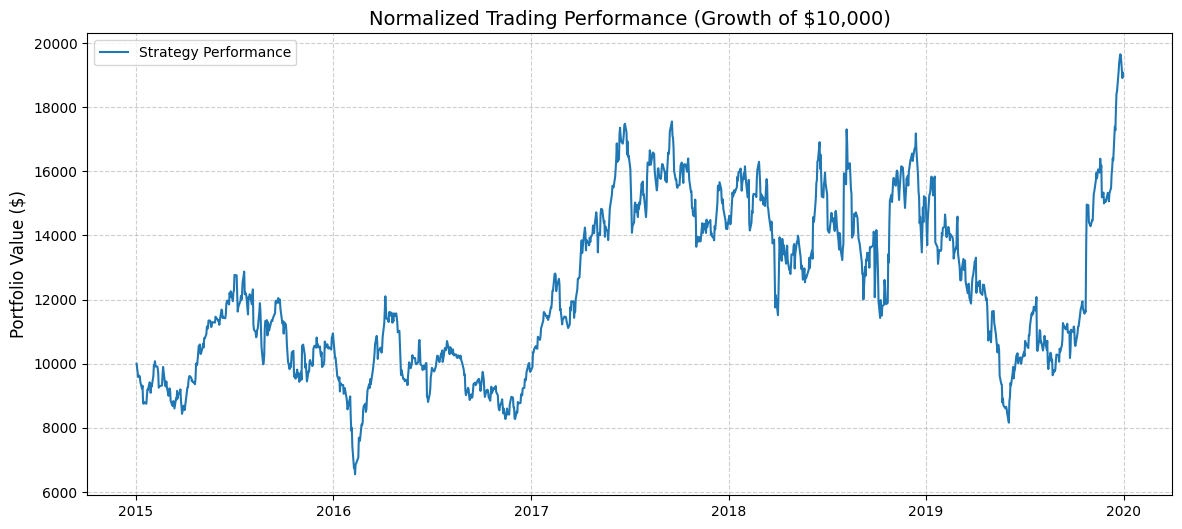

In [ ]:
# use Cumulative Return
df_daily['cumulative_returns'] = (1 + df_daily['daily_returns']).cumprod()
df_daily['portfolio_value_normalized'] = 10000 * df_daily['cumulative_returns']

# Linear Scale
plt.figure(figsize=(14, 6))
plt.plot(df_daily.index, df_daily['portfolio_value_normalized'], label='Strategy Performance')

plt.title('Normalized Trading Performance (Growth of $10,000)', fontsize=14)
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()